# AEX 荷指 Hurst 指数估计

使用 Oxford-Man Realized Volatility 的 AEX 指数 rv5 数据，选取五年窗口进行 Hurst 估计，用于与中国市场（沪深300）对比，判断 rough volatility 建模的适用性。

## 1. 导入与数据加载

In [1]:
import sys
sys.path.append('../models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HurstEstimator import HurstEstimator

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = ['Arial Unicode MS']

In [2]:
# 加载 Oxford-Man 数据，筛选 AEX 荷指
df_raw = pd.read_csv('../data/oxfordmanrealizedvolatilityindices.csv')
df_aex = df_raw[df_raw['Symbol'] == '.AEX'].copy()

# 解析日期，转为 naive datetime 便于切片
date_col = df_aex.columns[0]
df_aex['date'] = pd.to_datetime(df_aex[date_col], utc=True).dt.tz_localize(None)
df_aex = df_aex.set_index('date').sort_index()

# 过滤无效 rv5（0 或负值）
df_aex = df_aex[df_aex['rv5'] > 1e-12]

# 选取五年窗口：2013-01-01 ~ 2018-06-27
df = df_aex.loc['2013-01-01':'2018-06-27'].copy()

print(f"数据范围: {df.index[0].date()} ~ {df.index[-1].date()}")
print(f"交易日数: {len(df)}")

数据范围: 2013-01-02 ~ 2018-06-26
交易日数: 1401


## 2. Hurst 指数估计（q=2 变差回归）

输入为 log σ = 0.5 * log(rv5)，与 HurstEstimator 要求一致。

In [3]:
hurst = HurstEstimator()
log_vol_series = 0.5 * np.log(df['rv5'])  # log(σ)

START_IDX = 500  # 使用前 500 日估计参数
H, h_info = hurst.estimate_hurst_variogram(log_vol_series[:START_IDX], q=2.0)

print(f"Hurst 指数 H = {H:.4f} (R² = {h_info['r_squared']:.4f})")
print(f"二阶矩回归截距 {h_info['intercept']:.4f}, ν² = {np.exp(h_info['intercept'])}")

nu_sq = np.exp(h_info['intercept'])

Hurst 指数 H = 0.0912 (R² = 0.8091)
二阶矩回归截距 -2.2261, ν² = 0.10794596682105004


## 3. 变差图可视化

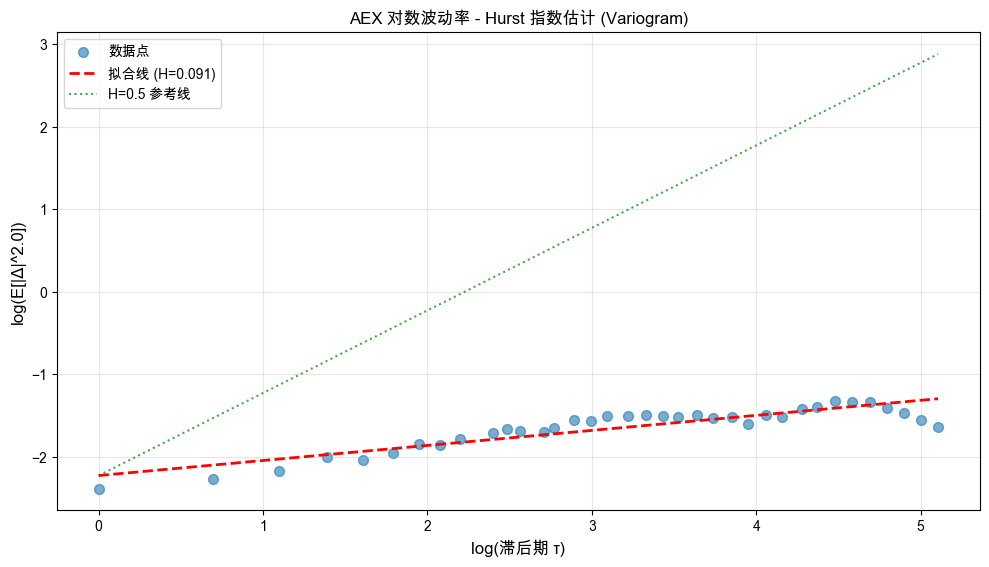

In [4]:
hurst.plot_variogram(log_vol_series[:START_IDX], q=2.0)
plt.title('AEX 对数波动率 - Hurst 指数估计 (Variogram)')
plt.show()

## 4. 粗糙性检验（可选）

In [5]:
test_result = hurst.estimate_hurst_roughness_test(log_vol_series[:START_IDX])
print(f"H = {test_result['H']:.3f}, is_rough: {test_result['is_rough']}")

H = 0.091, is_rough: True
